# Mental Health in Tech Survey - Exploratory Data Analysis (EDA)

**Dataset**: 2014 Survey measuring attitudes towards mental health and frequency of mental health disorders in the tech workplace.

---

## 1. Setup & Data Loading

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

print('Libraries loaded successfully!')

Libraries loaded successfully!


### Load Data from Colab Upload

In [3]:
from google.colab import files
print('Please upload survey.csv file:')
uploaded = files.upload()
df = pd.read_csv('survey.csv')

Please upload survey.csv file:


Saving survey.csv to survey (1).csv


---

## 2. Data Overview & Quality Check

In [6]:
# Display first few rows
print('First 5 rows:')
df.head()

First 5 rows:


,Timestamp,Age,Gender,Country,state,self_employed,family_history,treatment,work_interfere,no_employees,...,leave,mental_health_consequence,phys_health_consequence,coworkers,supervisor,mental_health_interview,phys_health_interview,mental_vs_physical,obs_consequence,comments
0,2014-08-27 11:29:31,37,Female,United States,IL,NaN,No,Yes,Often,6-25,...,Somewhat easy,No,No,Some of them,Yes,No,Maybe,Yes,No,NaN
1,2014-08-27 11:29:37,44,M,United States,IN,NaN,No,No,Rarely,More than 1000,...,Don't know,Maybe,No,No,No,No,No,Don't know,No,NaN
2,2014-08-27 11:29:44,32,Male,Canada,NaN,NaN,No,No,Rarely,6-25,...,Somewhat difficult,No,No,Yes,Yes,Yes,Yes,No,No,NaN
3,2014-08-27 11:29:46,31,Male,United Kingdom,NaN,NaN,Yes,Yes,Often,26-100,...,Somewhat difficult,Yes,Yes,Some of them,No,Maybe,Maybe,No,Yes,NaN
4,2014-08-27 11:30:22,31,Male,United States,TX,NaN,No,No,Never,100-500,...,Don't know,No,No,Some of them,Yes,Yes,Yes,Don't know,No,NaN


In [7]:
# Dataset Info
print('Dataset Information:')
df.info()

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1259 entries, 0 to 1258
Data columns (total 27 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   Timestamp                  1259 non-null   object
 1   Age                        1259 non-null   int64 
 2   Gender                     1259 non-null   object
 3   Country                    1259 non-null   object
 4   state                      744 non-null    object
 5   self_employed              1241 non-null   object
 6   family_history             1259 non-null   object
 7   treatment                  1259 non-null   object
 8   work_interfere             995 non-null    object
 9   no_employees               1259 non-null   object
 10  remote_work                1259 non-null   object
 11  tech_company               1259 non-null   object
 12  benefits                   1259 non-null   object
 13  care_options               1259 non-null  

        Column  Missing_Count  Missing_Percentage
      comments           1095               86.97
         state            515               40.91
work_interfere            264               20.97
 self_employed             18                1.43


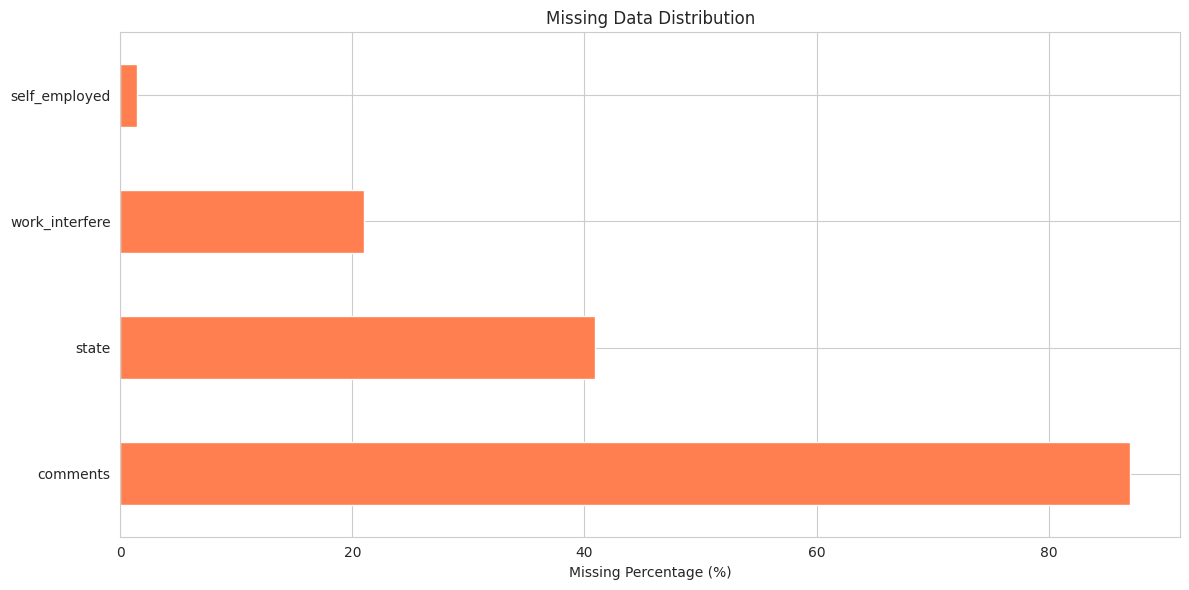

In [8]:
# Missing Values Analysis
missing_data = pd.DataFrame({
    'Column': df.columns,
    'Missing_Count': df.isnull().sum(),
    'Missing_Percentage': (df.isnull().sum() / len(df) * 100).round(2)
})
missing_data = missing_data[missing_data['Missing_Count'] > 0].sort_values('Missing_Percentage', ascending=False)
print(missing_data.to_string(index=False))

# Visualize missing data
plt.figure(figsize=(12, 6))
missing_pct = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)
missing_pct = missing_pct[missing_pct > 0]
missing_pct.plot(kind='barh', color='coral')
plt.xlabel('Missing Percentage (%)')
plt.title('Missing Data Distribution')
plt.tight_layout()
plt.show()

---

## 3. Data Cleaning

In [9]:
df_clean = df.copy()

# Standardize gender
gender_mapping = {
    'M': 'Male', 'Male': 'Male', 'male': 'Male', 'm': 'Male',
    'F': 'Female', 'Female': 'Female', 'female': 'Female', 'f': 'Female',
    'Femake': 'Female', 'femail': 'Female', 'Woman': 'Female', 'woman': 'Female',
    'Man': 'Male', 'cis male': 'Male', 'cis-male': 'Male'
}
df_clean['Gender'] = df_clean['Gender'].str.strip().map(lambda x: gender_mapping.get(x, 'Other'))

print('Gender values after cleaning:')
print(df_clean['Gender'].value_counts())

Gender values after cleaning:
Gender
Male      977
Female    244
Other      38
Name: count, dtype: int64


In [11]:
# Convert Timestamp to datetime
df_clean['Timestamp'] = pd.to_datetime(df_clean['Timestamp'])

# Clean Age (remove outliers)
df_clean = df_clean[(df_clean['Age'] >= 18) & (df_clean['Age'] <= 100)]
print(f'Remaining records after age cleaning: {len(df_clean)}')
print(f'Age range: {df_clean["Age"].min():.0f} - {df_clean["Age"].max():.0f}')

Remaining records after age cleaning: 1251
Age range: 18 - 72


In [12]:
# Keep top 10 countries, group others
top_countries = df_clean['Country'].value_counts().head(10).index.tolist()
df_clean['Country'] = df_clean['Country'].apply(lambda x: x if x in top_countries else 'Other')

print(f'Top countries: {len(top_countries)}')
print(df_clean['Country'].value_counts().head())

Top countries: 10
Country
United States     746
United Kingdom    184
Other              98
Canada             72
Germany            45
Name: count, dtype: int64


---

## 4. Demographics Analysis

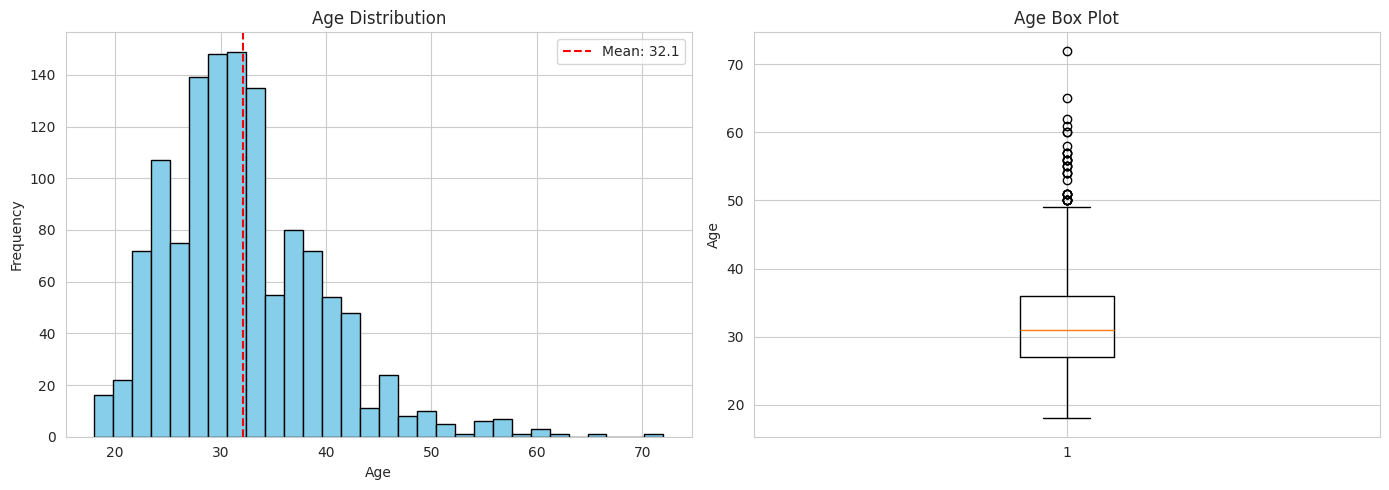

Age - Mean: 32.08, Median: 31.00, Std: 7.29


In [13]:
# Age Distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df_clean['Age'], bins=30, color='skyblue', edgecolor='black')
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Age Distribution')
axes[0].axvline(df_clean['Age'].mean(), color='red', linestyle='--', label=f'Mean: {df_clean["Age"].mean():.1f}')
axes[0].legend()

axes[1].boxplot(df_clean['Age'], vert=True)
axes[1].set_ylabel('Age')
axes[1].set_title('Age Box Plot')

plt.tight_layout()
plt.show()

print(f'Age - Mean: {df_clean["Age"].mean():.2f}, Median: {df_clean["Age"].median():.2f}, Std: {df_clean["Age"].std():.2f}')

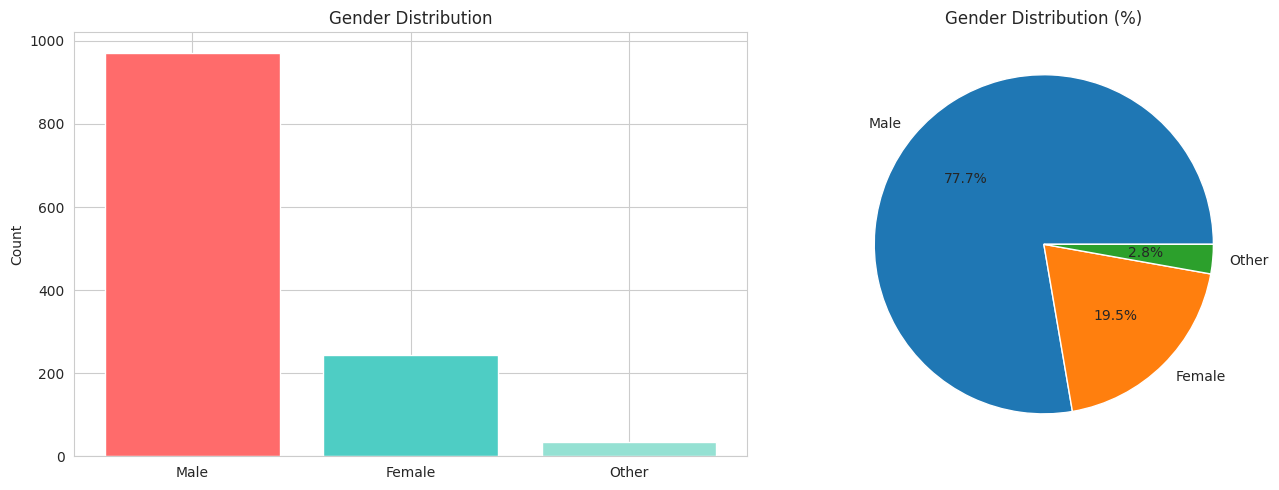

In [14]:
# Gender Distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

gender_counts = df_clean['Gender'].value_counts()
axes[0].bar(gender_counts.index, gender_counts.values, color=['#FF6B6B', '#4ECDC4', '#95E1D3'])
axes[0].set_title('Gender Distribution')
axes[0].set_ylabel('Count')

axes[1].pie(gender_counts.values, labels=gender_counts.index, autopct='%1.1f%%')
axes[1].set_title('Gender Distribution (%)')

plt.tight_layout()
plt.show()

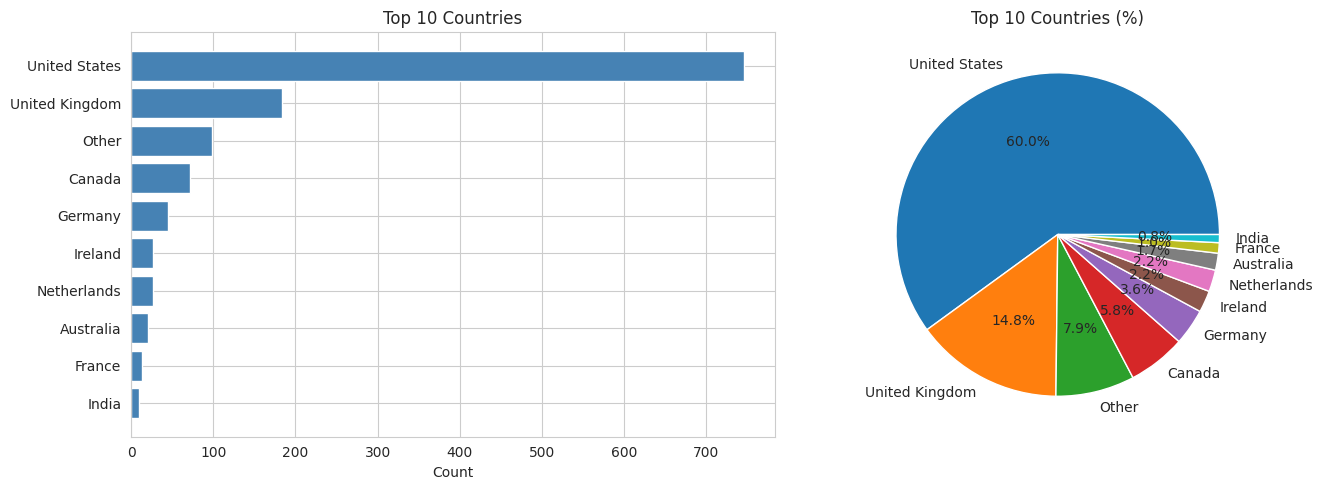

In [15]:
# Top Countries
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

country_counts = df_clean['Country'].value_counts().head(10)
axes[0].barh(country_counts.index, country_counts.values, color='steelblue')
axes[0].set_xlabel('Count')
axes[0].set_title('Top 10 Countries')
axes[0].invert_yaxis()

axes[1].pie(country_counts.values, labels=country_counts.index, autopct='%1.1f%%')
axes[1].set_title('Top 10 Countries (%)')

plt.tight_layout()
plt.show()

---

## 5. Mental Health & Treatment

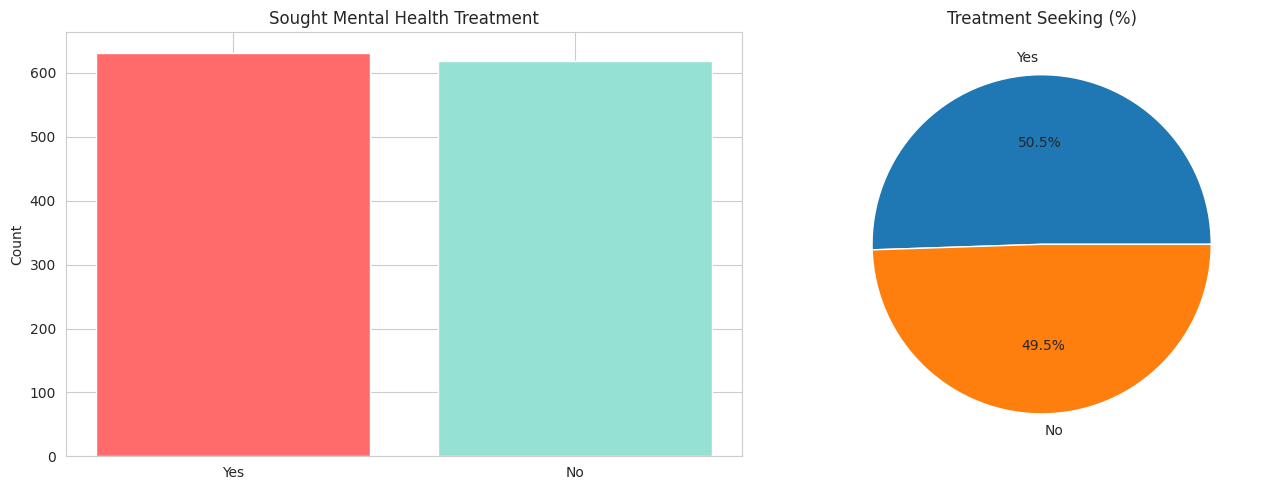

Percentage sought treatment: 50.52%


In [17]:
# Treatment Seeking
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

treatment_counts = df_clean['treatment'].value_counts()
axes[0].bar(treatment_counts.index, treatment_counts.values, color=['#FF6B6B', '#95E1D3'])
axes[0].set_title('Sought Mental Health Treatment')
axes[0].set_ylabel('Count')

axes[1].pie(treatment_counts.values, labels=treatment_counts.index, autopct='%1.1f%%')
axes[1].set_title('Treatment Seeking (%)')

plt.tight_layout()
plt.show()

pct = (treatment_counts.get('Yes', 0) / len(df_clean) * 100)
print(f'Percentage sought treatment: {pct:.2f}%')

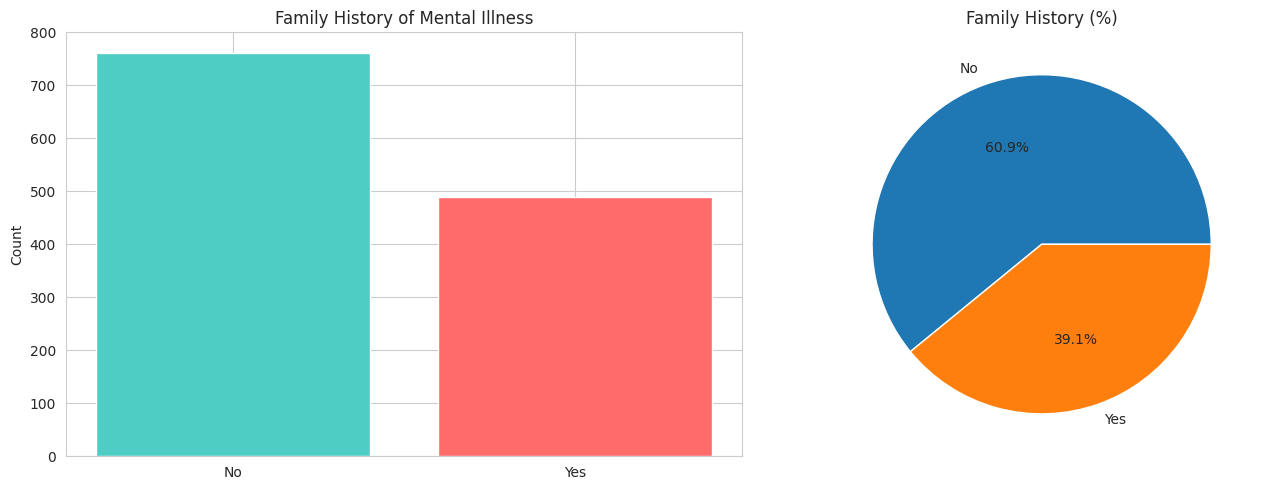

In [18]:
# Family History
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

family = df_clean['family_history'].value_counts()
axes[0].bar(family.index, family.values, color=['#4ECDC4', '#FF6B6B'])
axes[0].set_title('Family History of Mental Illness')
axes[0].set_ylabel('Count')

axes[1].pie(family.values, labels=family.index, autopct='%1.1f%%')
axes[1].set_title('Family History (%)')

plt.tight_layout()
plt.show()

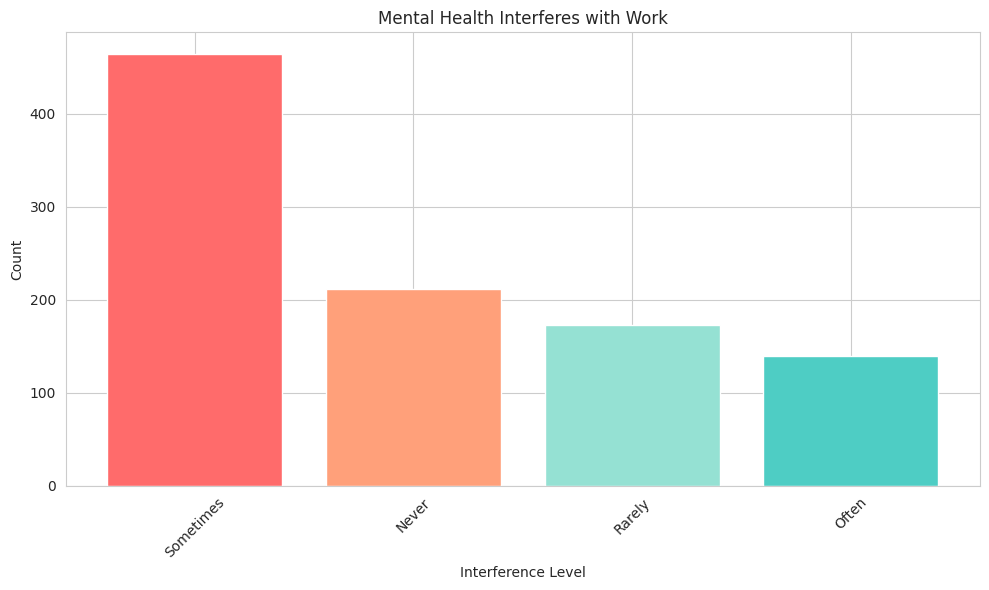

In [19]:
# Work Interference
fig, ax = plt.subplots(figsize=(10, 6))
work = df_clean['work_interfere'].value_counts()
ax.bar(work.index, work.values, color=['#FF6B6B', '#FFA07A', '#95E1D3', '#4ECDC4'])
ax.set_title('Mental Health Interferes with Work')
ax.set_ylabel('Count')
ax.set_xlabel('Interference Level')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

---

## 6. Workplace Benefits & Support

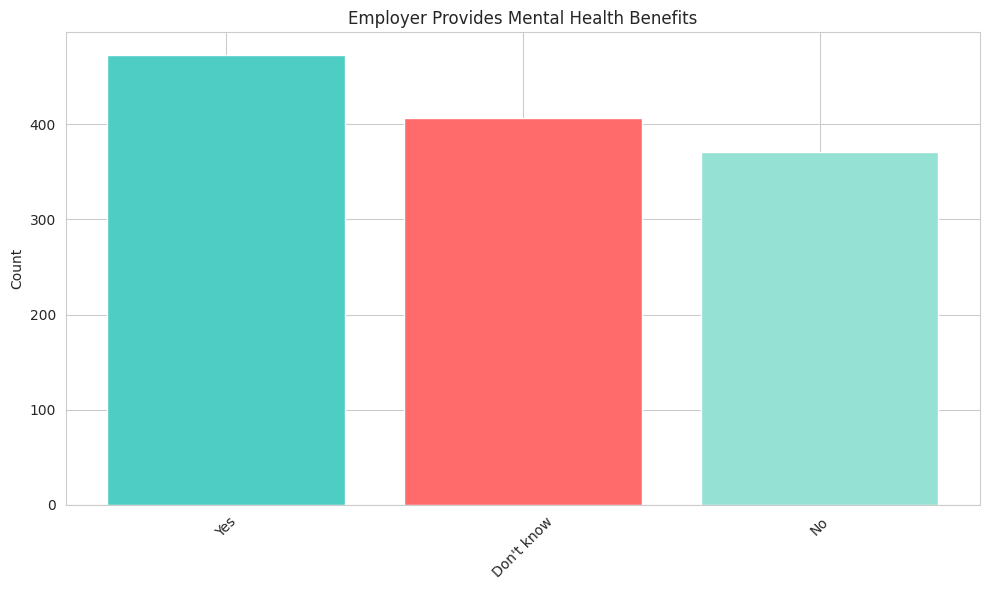

Percentage with benefits: 37.81%


In [20]:
# Mental Health Benefits
fig, ax = plt.subplots(figsize=(10, 6))
benefits = df_clean['benefits'].value_counts()
ax.bar(benefits.index, benefits.values, color=['#4ECDC4', '#FF6B6B', '#95E1D3'])
ax.set_title('Employer Provides Mental Health Benefits')
ax.set_ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

pct = (benefits.get('Yes', 0) / len(df_clean) * 100)
print(f'Percentage with benefits: {pct:.2f}%')

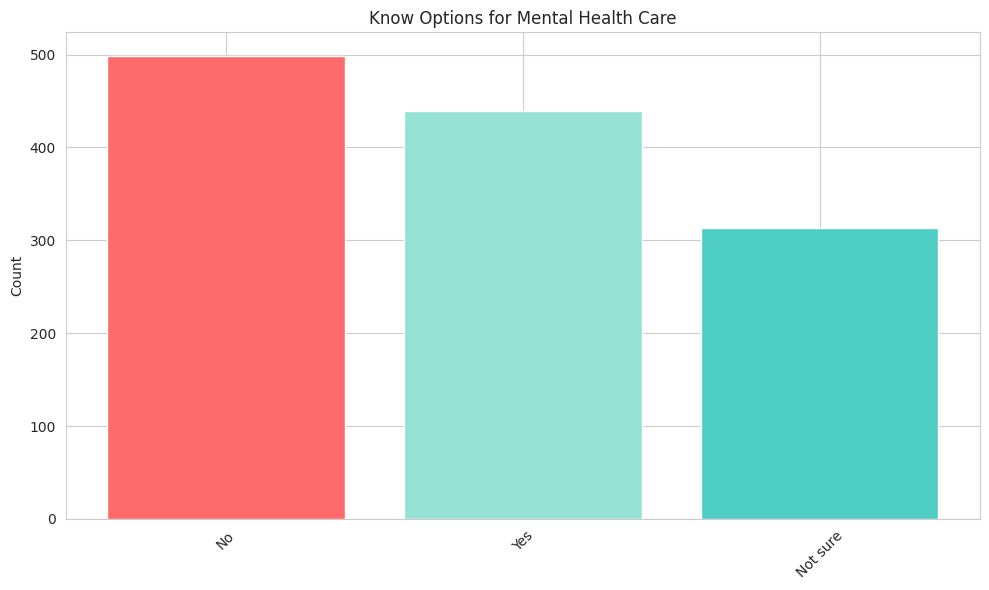

In [21]:
# Care Options Knowledge
fig, ax = plt.subplots(figsize=(10, 6))
care = df_clean['care_options'].value_counts()
ax.bar(care.index, care.values, color=['#FF6B6B', '#95E1D3', '#4ECDC4'])
ax.set_title('Know Options for Mental Health Care')
ax.set_ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

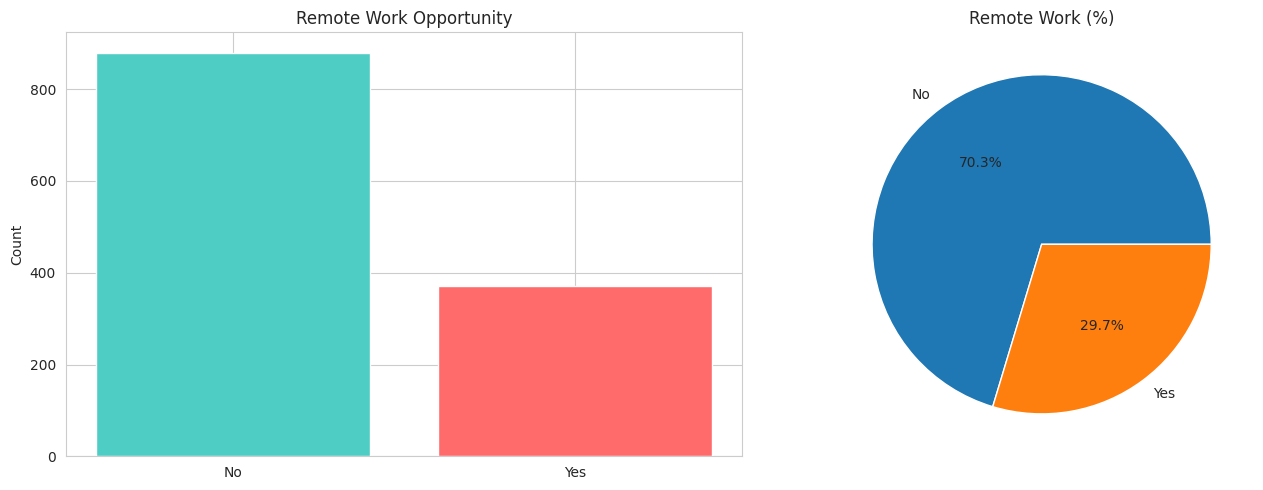

In [22]:
# Remote Work
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

remote = df_clean['remote_work'].value_counts()
axes[0].bar(remote.index, remote.values, color=['#4ECDC4', '#FF6B6B'])
axes[0].set_title('Remote Work Opportunity')
axes[0].set_ylabel('Count')

axes[1].pie(remote.values, labels=remote.index, autopct='%1.1f%%')
axes[1].set_title('Remote Work (%)')

plt.tight_layout()
plt.show()

---

## 7. Workplace Stigma & Attitudes

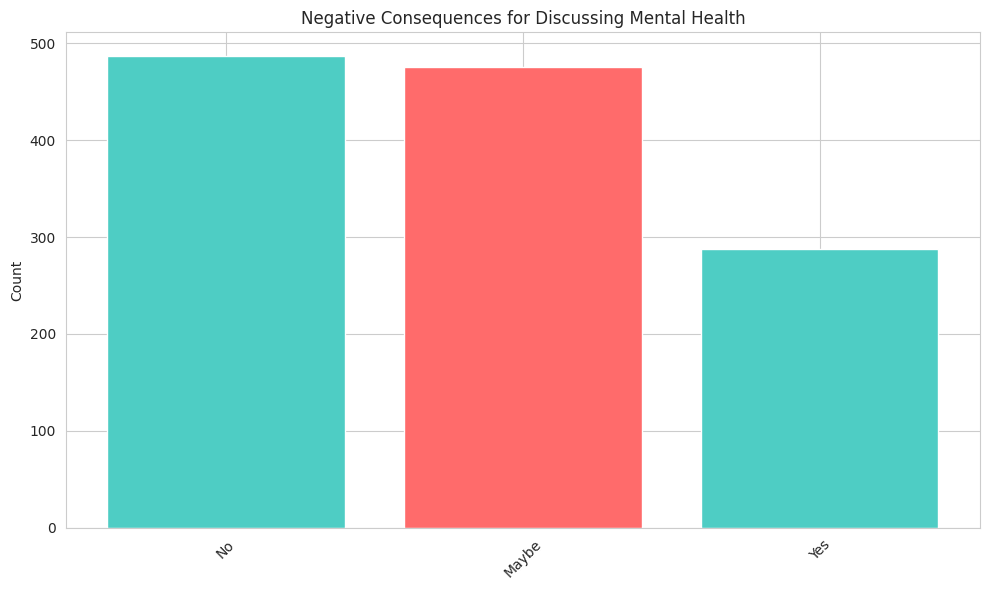

Fear negative consequences: 23.02%


In [23]:
# Mental Health Consequences
fig, ax = plt.subplots(figsize=(10, 6))
consequence = df_clean['mental_health_consequence'].value_counts()
ax.bar(consequence.index, consequence.values, color=['#4ECDC4', '#FF6B6B'])
ax.set_title('Negative Consequences for Discussing Mental Health')
ax.set_ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

pct = (consequence.get('Yes', 0) / len(df_clean) * 100)
print(f'Fear negative consequences: {pct:.2f}%')

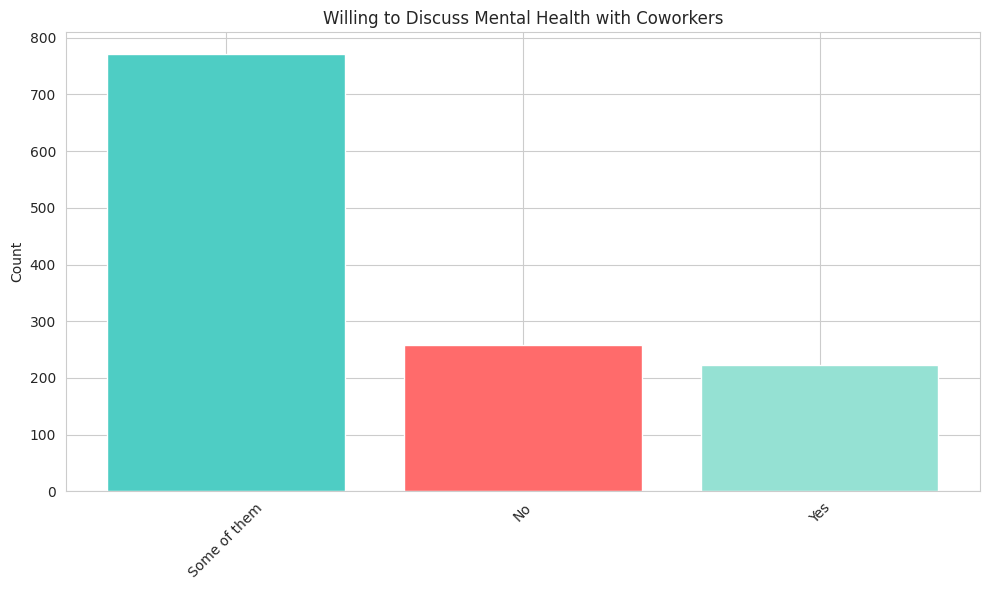

In [24]:
# Discuss with Coworkers
fig, ax = plt.subplots(figsize=(10, 6))
coworkers = df_clean['coworkers'].value_counts()
ax.bar(coworkers.index, coworkers.values, color=['#4ECDC4', '#FF6B6B', '#95E1D3'])
ax.set_title('Willing to Discuss Mental Health with Coworkers')
ax.set_ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

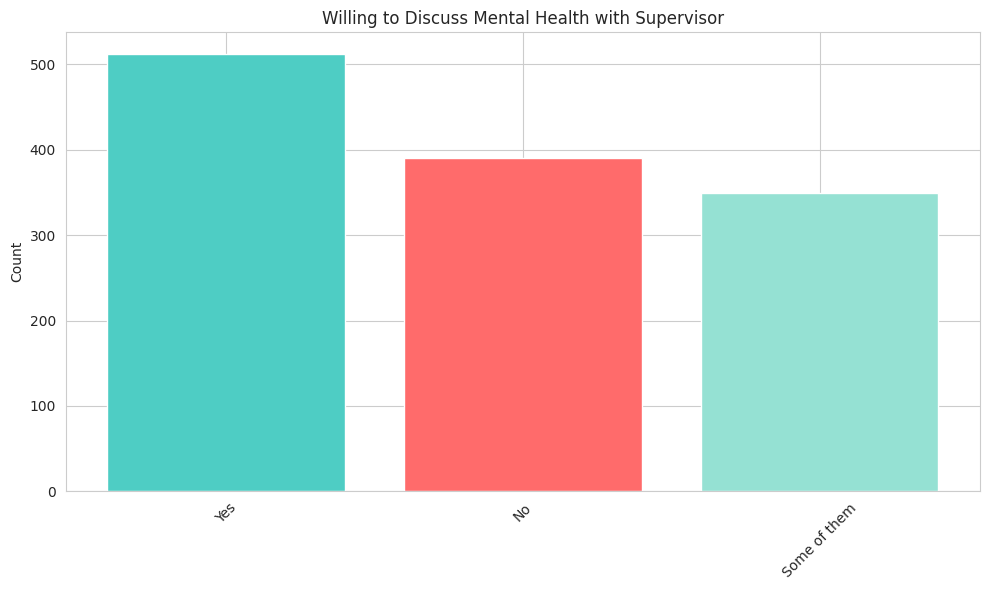

In [25]:
# Discuss with Supervisor
fig, ax = plt.subplots(figsize=(10, 6))
supervisor = df_clean['supervisor'].value_counts()
ax.bar(supervisor.index, supervisor.values, color=['#4ECDC4', '#FF6B6B', '#95E1D3'])
ax.set_title('Willing to Discuss Mental Health with Supervisor')
ax.set_ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

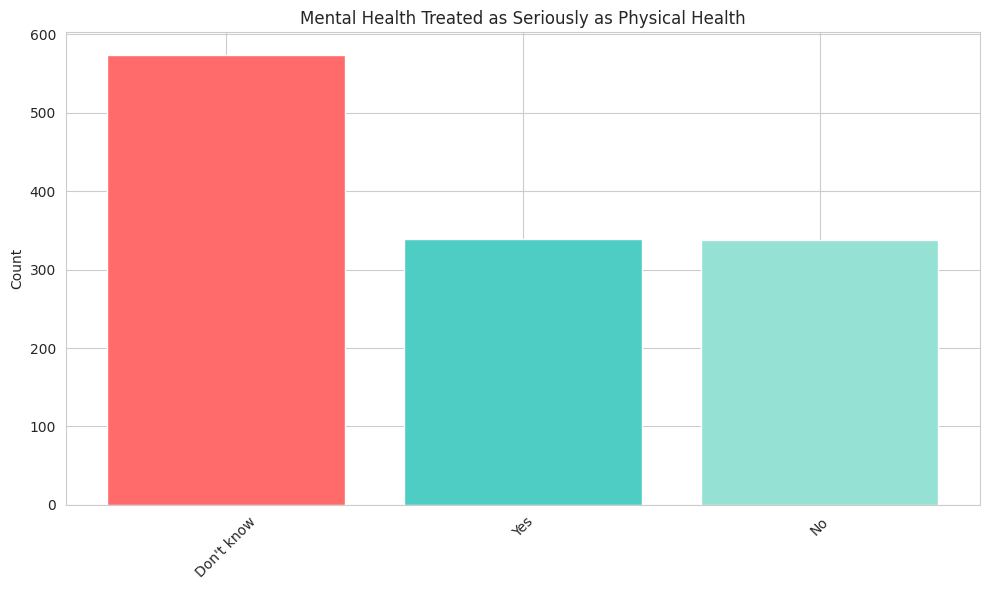

In [26]:
# Mental vs Physical
fig, ax = plt.subplots(figsize=(10, 6))
mvp = df_clean['mental_vs_physical'].value_counts()
ax.bar(mvp.index, mvp.values, color=['#FF6B6B', '#4ECDC4', '#95E1D3'])
ax.set_title('Mental Health Treated as Seriously as Physical Health')
ax.set_ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

---

## 8. Geographic Variation

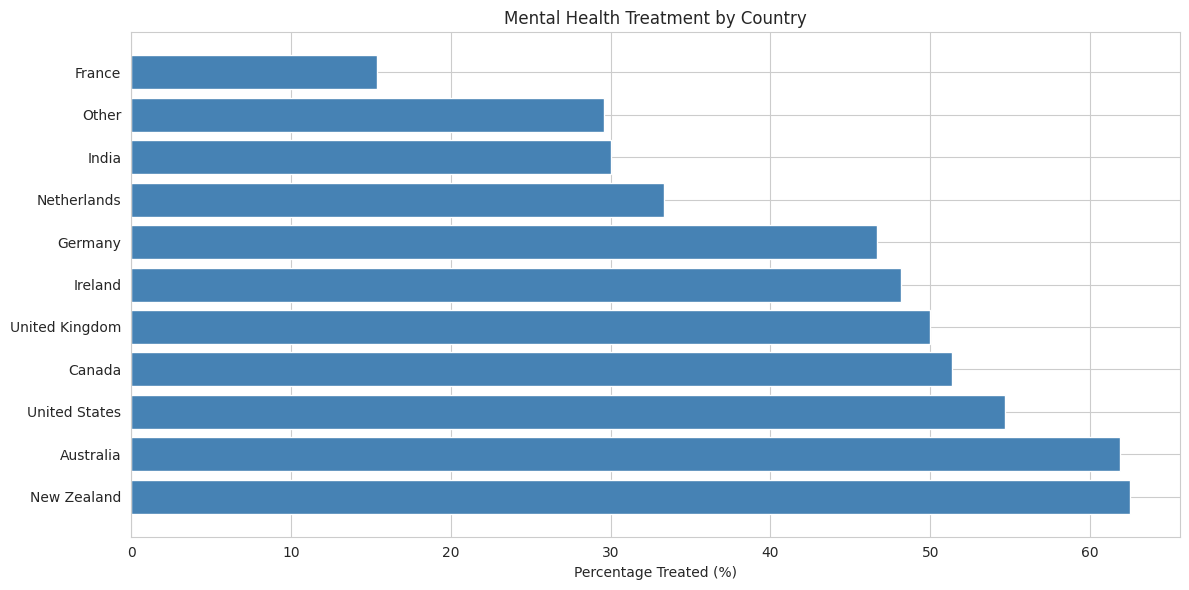

In [27]:
# Treatment by Country
treatment_country = df_clean[df_clean['treatment'].notna()].groupby('Country')['treatment'].value_counts().unstack(fill_value=0)
treatment_country['Total'] = treatment_country.sum(axis=1)
treatment_country['Pct_Treated'] = (treatment_country.get('Yes', 0) / treatment_country['Total'] * 100).round(2)
treatment_country = treatment_country.sort_values('Pct_Treated', ascending=False)

fig, ax = plt.subplots(figsize=(12, 6))
ax.barh(treatment_country.index, treatment_country['Pct_Treated'], color='steelblue')
ax.set_xlabel('Percentage Treated (%)')
ax.set_title('Mental Health Treatment by Country')
plt.tight_layout()
plt.show()

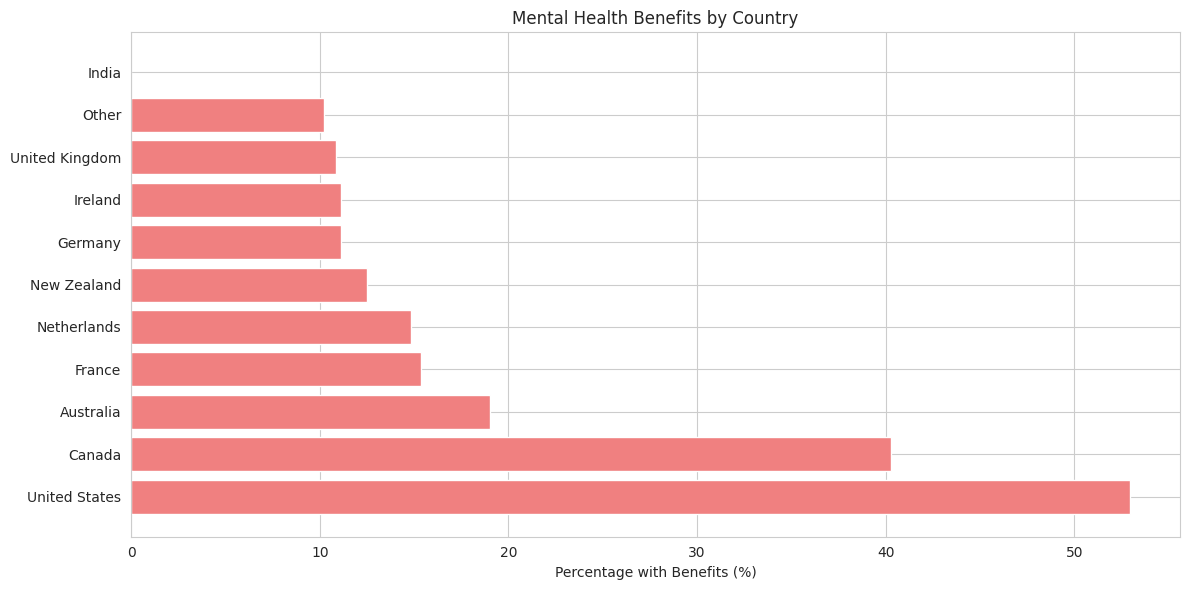

In [28]:
# Benefits by Country
benefits_country = df_clean[df_clean['benefits'].notna()].groupby('Country')['benefits'].value_counts().unstack(fill_value=0)
benefits_country['Total'] = benefits_country.sum(axis=1)
benefits_country['Pct_Benefits'] = (benefits_country.get('Yes', 0) / benefits_country['Total'] * 100).round(2)
benefits_country = benefits_country.sort_values('Pct_Benefits', ascending=False)

fig, ax = plt.subplots(figsize=(12, 6))
ax.barh(benefits_country.index, benefits_country['Pct_Benefits'], color='lightcoral')
ax.set_xlabel('Percentage with Benefits (%)')
ax.set_title('Mental Health Benefits by Country')
plt.tight_layout()
plt.show()

---

## 9. Demographic Correlations

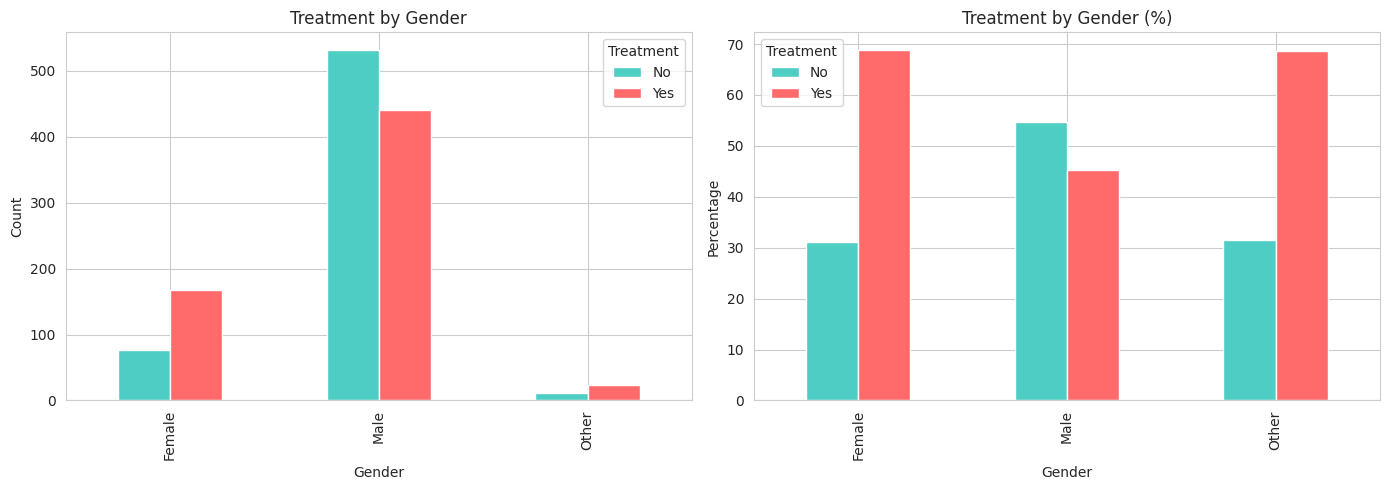

In [29]:
# Treatment by Gender
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

treat_gender = df_clean[df_clean['treatment'].notna()].groupby('Gender')['treatment'].value_counts().unstack(fill_value=0)
treat_gender.plot(kind='bar', ax=axes[0], color=['#4ECDC4', '#FF6B6B'])
axes[0].set_title('Treatment by Gender')
axes[0].set_ylabel('Count')
axes[0].legend(title='Treatment')

treat_gender_pct = treat_gender.div(treat_gender.sum(axis=1), axis=0) * 100
treat_gender_pct.plot(kind='bar', ax=axes[1], color=['#4ECDC4', '#FF6B6B'])
axes[1].set_title('Treatment by Gender (%)')
axes[1].set_ylabel('Percentage')
axes[1].legend(title='Treatment')

plt.tight_layout()
plt.show()

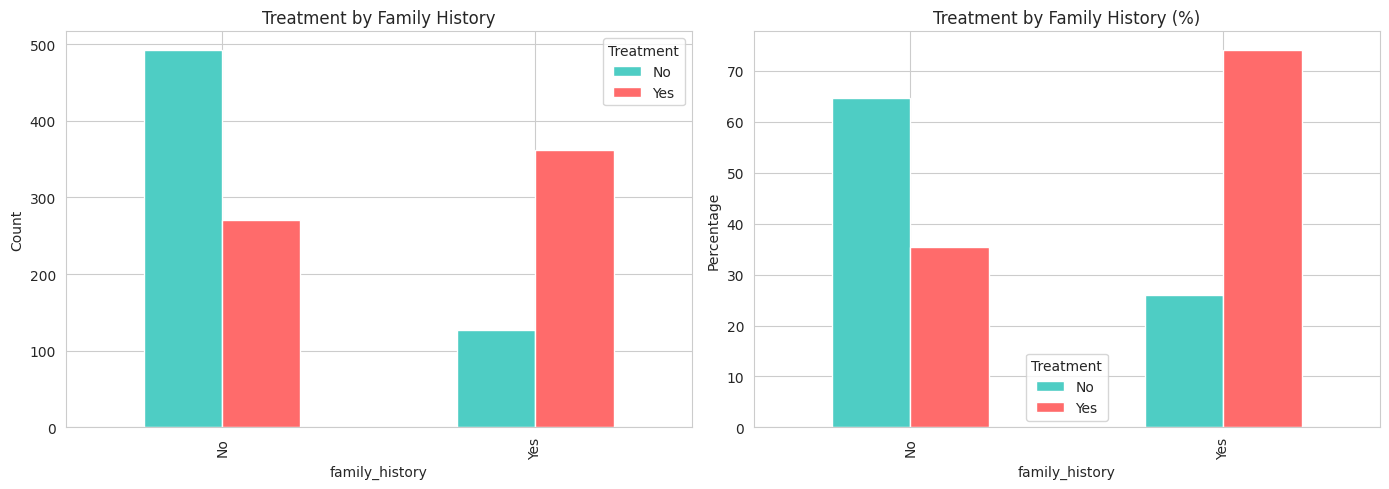

Chi-square: 175.9552, p-value: 3.7036e-40, Significant: Yes


In [30]:
# Family History vs Treatment (with Chi-square)
from scipy.stats import chi2_contingency

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

family_treat = df_clean[df_clean['treatment'].notna()].groupby('family_history')['treatment'].value_counts().unstack(fill_value=0)
family_treat.plot(kind='bar', ax=axes[0], color=['#4ECDC4', '#FF6B6B'])
axes[0].set_title('Treatment by Family History')
axes[0].set_ylabel('Count')
axes[0].legend(title='Treatment')

family_treat_pct = family_treat.div(family_treat.sum(axis=1), axis=0) * 100
family_treat_pct.plot(kind='bar', ax=axes[1], color=['#4ECDC4', '#FF6B6B'])
axes[1].set_title('Treatment by Family History (%)')
axes[1].set_ylabel('Percentage')
axes[1].legend(title='Treatment')

plt.tight_layout()
plt.show()

# Chi-square test
contingency = pd.crosstab(df_clean['family_history'], df_clean['treatment'])
chi2, p_val, dof, exp = chi2_contingency(contingency)
print(f'Chi-square: {chi2:.4f}, p-value: {p_val:.4e}, Significant: {"Yes" if p_val < 0.05 else "No"}')

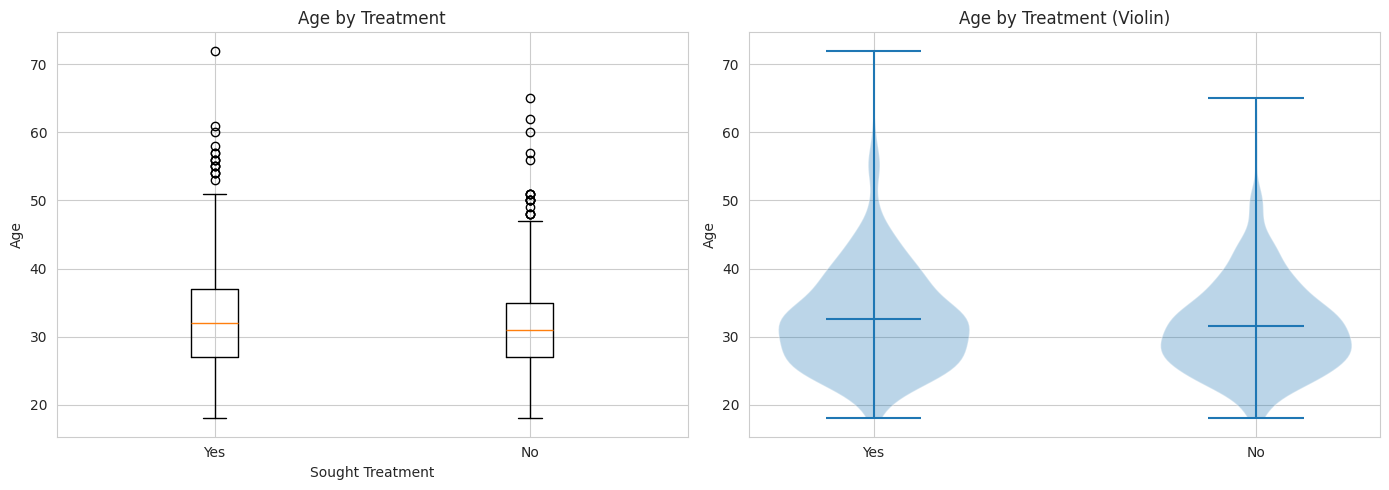

Age - Yes Mean: 32.61, No Mean: 31.53
T-test: t=2.6092, p=9.1849e-03, Significant: Yes


In [31]:
# Age vs Treatment
from scipy.stats import ttest_ind

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

yes_ages = df_clean[df_clean['treatment'] == 'Yes']['Age'].dropna()
no_ages = df_clean[df_clean['treatment'] == 'No']['Age'].dropna()

axes[0].boxplot([yes_ages, no_ages], labels=['Yes', 'No'])
axes[0].set_ylabel('Age')
axes[0].set_xlabel('Sought Treatment')
axes[0].set_title('Age by Treatment')

axes[1].violinplot([yes_ages, no_ages], positions=[1, 2], showmeans=True)
axes[1].set_xticks([1, 2])
axes[1].set_xticklabels(['Yes', 'No'])
axes[1].set_ylabel('Age')
axes[1].set_title('Age by Treatment (Violin)')

plt.tight_layout()
plt.show()

t_stat, p_val = ttest_ind(yes_ages, no_ages)
print(f'Age - Yes Mean: {yes_ages.mean():.2f}, No Mean: {no_ages.mean():.2f}')
print(f'T-test: t={t_stat:.4f}, p={p_val:.4e}, Significant: {"Yes" if p_val < 0.05 else "No"}')

---

## 10. Workplace Environment

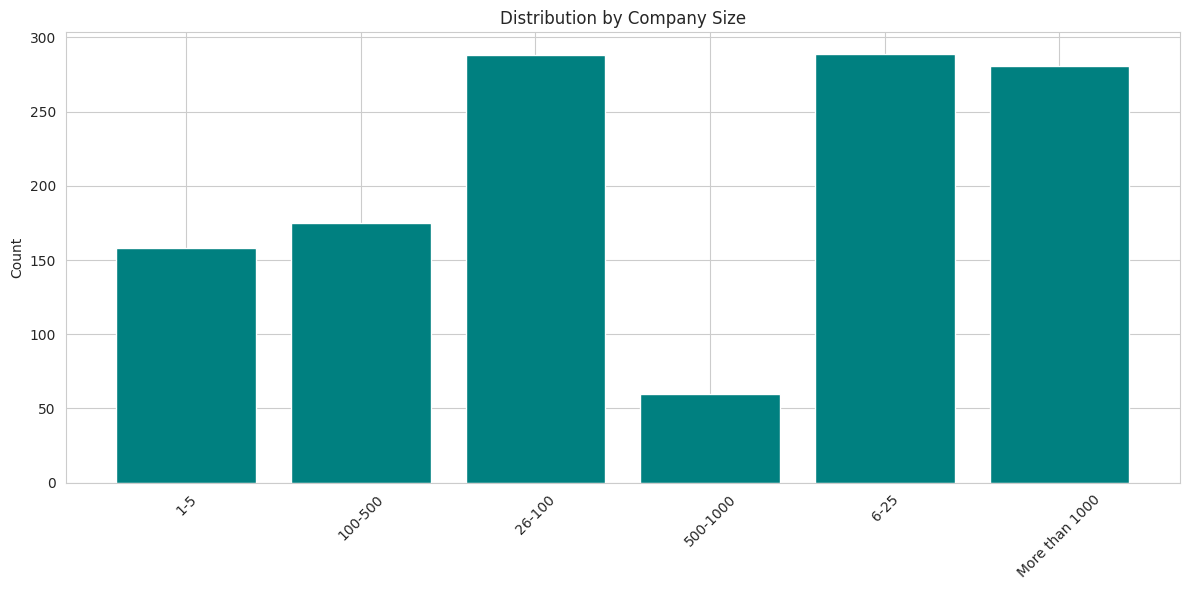

In [32]:
# Company Size
fig, ax = plt.subplots(figsize=(12, 6))
company_size = df_clean['no_employees'].value_counts().sort_index()
ax.bar(range(len(company_size)), company_size.values, color='teal')
ax.set_xticks(range(len(company_size)))
ax.set_xticklabels(company_size.index, rotation=45)
ax.set_title('Distribution by Company Size')
ax.set_ylabel('Count')
plt.tight_layout()
plt.show()

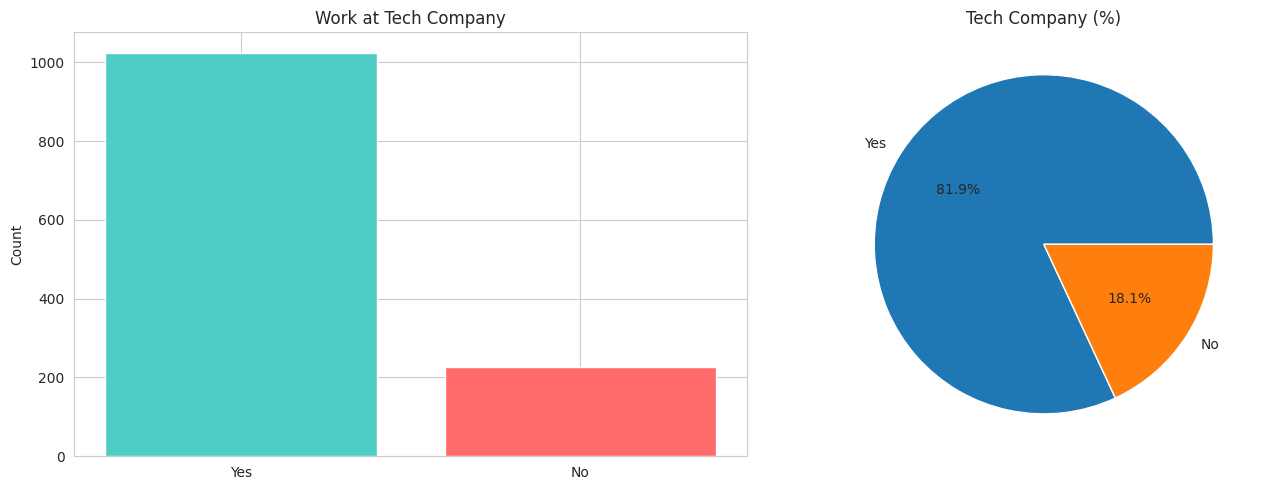

In [33]:
# Tech Company
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

tech = df_clean['tech_company'].value_counts()
axes[0].bar(tech.index, tech.values, color=['#4ECDC4', '#FF6B6B', '#95E1D3'])
axes[0].set_title('Work at Tech Company')
axes[0].set_ylabel('Count')

axes[1].pie(tech.values, labels=tech.index, autopct='%1.1f%%')
axes[1].set_title('Tech Company (%)')

plt.tight_layout()
plt.show()

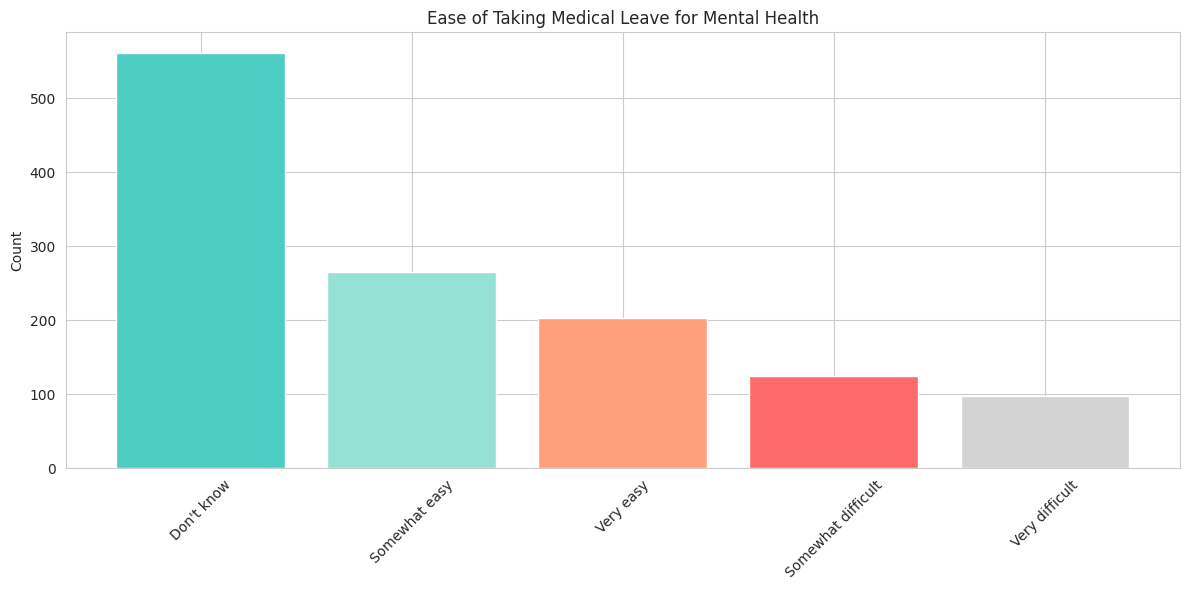

In [34]:
# Medical Leave
fig, ax = plt.subplots(figsize=(12, 6))
leave = df_clean['leave'].value_counts()
ax.bar(range(len(leave)), leave.values, color=['#4ECDC4', '#95E1D3', '#FFA07A', '#FF6B6B', '#D3D3D3'][:len(leave)])
ax.set_xticks(range(len(leave)))
ax.set_xticklabels(leave.index, rotation=45)
ax.set_title('Ease of Taking Medical Leave for Mental Health')
ax.set_ylabel('Count')
plt.tight_layout()
plt.show()

---

## 11. Key Insights Summary

In [35]:
print('='*80)
print('KEY INSIGHTS SUMMARY')
print('='*80)

print(f'\nTotal Respondents: {len(df_clean):,}')
print(f'Survey Period: {df_clean["Timestamp"].min().date()} to {df_clean["Timestamp"].max().date()}')
print(f'Age Range: {df_clean["Age"].min():.0f} - {df_clean["Age"].max():.0f} (Mean: {df_clean["Age"].mean():.1f})')

treatment_yes = (df_clean['treatment'] == 'Yes').sum()
family_yes = (df_clean['family_history'] == 'Yes').sum()
benefits_yes = (df_clean['benefits'] == 'Yes').sum()
remote_yes = (df_clean['remote_work'] == 'Yes').sum()
tech_yes = (df_clean['tech_company'] == 'Yes').sum()

print(f'\nMental Health Treatment: {treatment_yes} ({treatment_yes/len(df_clean)*100:.1f}%)')
print(f'Family History: {family_yes} ({family_yes/len(df_clean)*100:.1f}%)')
print(f'Employer Benefits: {benefits_yes} ({benefits_yes/len(df_clean)*100:.1f}%)')
print(f'Remote Work: {remote_yes} ({remote_yes/len(df_clean)*100:.1f}%)')
print(f'Tech Company: {tech_yes} ({tech_yes/len(df_clean)*100:.1f}%)')

print(f'\nKey Findings:')
print(f'  ✓ Geographic variations in mental health awareness')
print(f'  ✓ Strong correlation between family history and treatment')
print(f'  ✓ Workplace support infrastructure varies significantly')
print(f'  ✓ Stigma remains a barrier to disclosure')
print(f'  ✓ Gender differences in treatment-seeking behavior')

KEY INSIGHTS SUMMARY

Total Respondents: 1,251
Survey Period: 2014-08-27 to 2016-02-01
Age Range: 18 - 72 (Mean: 32.1)

Mental Health Treatment: 632 (50.5%)
Family History: 489 (39.1%)
Employer Benefits: 473 (37.8%)
Remote Work: 371 (29.7%)
Tech Company: 1025 (81.9%)

Key Findings:
  ✓ Geographic variations in mental health awareness
  ✓ Strong correlation between family history and treatment
  ✓ Workplace support infrastructure varies significantly
  ✓ Stigma remains a barrier to disclosure
  ✓ Gender differences in treatment-seeking behavior
